In [54]:
import sys
sys.path.append('utils')


In [55]:
import pandas as pd
import numpy as np

In [56]:
# ============================================================
# KONFIGURACJA PUNKTU - zmień tylko wartości dla nowego punktu
# ============================================================
PLIK_CSV = 'Quantity.csv'          # nazwa pliku CSV
MIASTO = 'Toruń'
NAZWA_PUNKTU = 'Skrzyżowanie Łódzka - Generała Władysława Andersa '   # nazwa punktu pomiarowego
NR_PUNKTU = '2'                        # numer rozdziału
NR_TABELI_START = 21                   # numer pierwszej tabeli
DATA_POMIARU = '27 maja 2026'
TEMPERATURA = '+20°C'
DZIEN_TYGODNIA = 'Środa (dzień roboczy)'

# Mapowanie litery kierunku z AISP -> (wlot, typ relacji: Prawo/Lewo/Wprost/Zawracający)
# Litery i ich znaczenie zależą od geometrii konkretnego skrzyżowania w AISP - dostosuj ręcznie per punkt
KIERUNEK_MAPPING = {
    'A': ('PD', 'Prawo'),
    'B': ('PD', 'Wprost'),
    'C': ('PD', 'Lewo'),
    'D': ('WSCH', 'Lewo'),
    'E': ('WSCH', 'Wprost'),
    'F': ('WSCH', 'Prawo'),
    'G': ('ZACH', 'Lewo'),
    'H': ('ZACH', 'Wprost'),
    'I': ('ZACH', 'Wprost'),
    'J': ('ZACH', 'Prawo'),
    'K': ('PN', 'Wprost'),
    'L': ('PN', 'Wprost'),
    'M': ('PN', 'Lewo'),
    'N': ('PN', 'Prawo'),
}

# Kolejność kierunków w tabelach i na wykresach
KOLEJNOSC_KIERUNKOW = [
    'B', 'A', 'C', 'E', 'D', 'F',
    'G', 'I', 'J', 'H', 'M', 'K',
    'L', 'N'
]

# Kategorie pojazdów mechanicznych (bez niezmotoryzowanych) - używane do SDR/szczytu
KATEGORIE_MECHANICZNE = [
    'b.moto', 'c.osobowe', 'c3.mikrobusy', 'd.dostawcze',
    'e.ciezarowe', 'f.ciezarowe.z.naczepami', 'g.autobusy', 'h.rolne'
]

# Kategorie niezmotoryzowane
KATEGORIE_NIEZMOT = ['rowery', 'hulajnogi', 'pieszy', 'pieszy potrzeby']

# ============================================================
# STYL WYKRESÓW - Orange Polska brand
# ============================================================
import matplotlib.pyplot as plt

ORANGE = '#FF7900'
BLACK = '#000000'
GREY_DARK = '#4A4A4A'
GREY_MED = '#8C8C8C'
GREY_LIGHT = '#D6D6D6'
WHITE = '#FFFFFF'

# Paleta 3-seryjna (pory doby): akcent orange na najważniejszej serii, szarości na pozostałych
PALETTE_PORY = [ORANGE, GREY_DARK, GREY_LIGHT]

# Paleta wieloseryjna (np. wykres godzinowy wg relacji) - tonacja orange/szarość/czerń
PALETTE_QUALITATIVE = [
    ORANGE, GREY_DARK, GREY_MED, '#C86400', BLACK, GREY_LIGHT,
    '#FFB400', '#B0B0B0', '#FFD9A6', '#666666', '#FFA940', '#999999', '#E8590C', '#D9A066'
]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.edgecolor': GREY_MED,
    'axes.labelcolor': GREY_DARK,
    'text.color': GREY_DARK,
    'xtick.color': GREY_DARK,
    'ytick.color': GREY_DARK,
    'axes.titleweight': 'bold',
    'axes.titlecolor': BLACK,
    'figure.facecolor': WHITE,
    'axes.facecolor': WHITE,
    'savefig.facecolor': WHITE,
})

In [57]:
# MODUŁ 1: WCZYTANIE I WALIDACJA
# ============================================================
df = pd.read_csv(PLIK_CSV, sep=';', encoding='cp1250')
df['Czas'] = pd.to_datetime(df['Czas'])
df['Godzina'] = df['Czas'].dt.hour

# --- Walidacja ---
print(f"{'='*60}")
print(f"PUNKT: {NAZWA_PUNKTU}")
print(f"{'='*60}")
print(f"Wierszy: {len(df)}  |  Kolumny: {len(df.columns)}")
print(f"Kierunki: {sorted(df['Kierunek'].unique())}")
print(f"Godziny: {sorted(df['Godzina'].unique())}")

# Sprawdzenie kompletności: powinno być 144 wiersze (6 kier × 24h)
# assert len(df) == 144, f"BŁĄD: oczekiwano 144 wierszy, jest {len(df)}"

# Weryfikacja sumy z raportem
suma_check = df[KATEGORIE_MECHANICZNE].sum().sum()
print(f"\nSDR ŁĄCZNY: {int(suma_check):,} poj./dobę".replace(',', ' '))
print(f"{'='*60}")


PUNKT: Skrzyżowanie Łódzka - Generała Władysława Andersa 
Wierszy: 336  |  Kolumny: 15
Kierunki: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N']
Godziny: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

SDR ŁĄCZNY: 31 185 poj./dobę


In [58]:
# MODUŁ 2: SDR I SZCZYTY PER KIERUNEK
# ============================================================
sdr_kierunki = {}
szczyt_kierunki = {}
godz_szczytu = {}

for kierunek in KOLEJNOSC_KIERUNKOW:
    df_k = df[df['Kierunek'] == kierunek]
    sdr_kierunki[kierunek] = int(df_k[KATEGORIE_MECHANICZNE].sum().sum())
    suma_godz = df_k[KATEGORIE_MECHANICZNE].sum(axis=1)
    szczyt_kierunki[kierunek] = int(suma_godz.max())
    godz_szczytu[kierunek] = int(df_k.loc[suma_godz.idxmax(), 'Godzina'])

sdr_total = sum(sdr_kierunki.values())

# Szczyt całkowity
df['_suma_godz'] = df[KATEGORIE_MECHANICZNE].sum(axis=1)
szczyt_total = int(df.groupby('Godzina')['_suma_godz'].sum().max())
godz_szczytu_total = int(df.groupby('Godzina')['_suma_godz'].sum().idxmax())

print(f"SDR total: {sdr_total:,} poj./dobę".replace(',', ' '))
print(f"Szczyt:    {szczyt_total} poj./h o godz. {godz_szczytu_total:02d}:00")
print()
for k in KOLEJNOSC_KIERUNKOW:
    print(f"  {k}: SDR={sdr_kierunki[k]:>5}  |  szczyt={szczyt_kierunki[k]:>4} poj./h  o {godz_szczytu[k]:02d}:00")


SDR total: 31 185 poj./dobę
Szczyt:    2352 poj./h o godz. 15:00

  B: SDR= 1948  |  szczyt= 160 poj./h  o 18:00
  A: SDR=  939  |  szczyt=  71 poj./h  o 11:00
  C: SDR=  482  |  szczyt=  48 poj./h  o 15:00
  E: SDR= 4039  |  szczyt= 335 poj./h  o 07:00
  D: SDR=  931  |  szczyt=  87 poj./h  o 15:00
  F: SDR=  688  |  szczyt=  67 poj./h  o 17:00
  G: SDR= 1680  |  szczyt= 168 poj./h  o 15:00
  I: SDR= 3362  |  szczyt= 250 poj./h  o 15:00
  J: SDR= 6024  |  szczyt= 492 poj./h  o 16:00
  H: SDR= 2501  |  szczyt= 240 poj./h  o 15:00
  M: SDR= 2727  |  szczyt= 206 poj./h  o 07:00
  K: SDR= 2084  |  szczyt= 186 poj./h  o 18:00
  L: SDR= 2732  |  szczyt= 186 poj./h  o 07:00
  N: SDR= 1048  |  szczyt=  84 poj./h  o 16:00


In [59]:

# MODUŁ 3: TABELA PARAMETRÓW POMIARU
# ============================================================
NR_TAB_PARAM = NR_TABELI_START

params = {
    'Parametr': [
        'Data pomiaru', 'Czas rozpoczęcia', 'Czas zakończenia',
        'Czas trwania', 'SDR', 'Szczyt ruchu', 'Dzień tygodnia',
        'Warunki atmosferyczne', 'Metoda pomiaru'
    ],
    'Wartość': [
        DATA_POMIARU,
        f"{DATA_POMIARU.split()[0]}.{DATA_POMIARU.split()[1][:2]}.{DATA_POMIARU.split()[2]} 00:00:00",
        f"{DATA_POMIARU.split()[0]}.{DATA_POMIARU.split()[1][:2]}.{DATA_POMIARU.split()[2]} 23:59:59",
        '24 godziny',
        f"{sdr_total:,} poj./dobę".replace(',', ' '),
        f"{szczyt_total} poj./h o godz. {godz_szczytu_total:02d}:00",
        DZIEN_TYGODNIA,
        f"Bez opadów, temperatura {TEMPERATURA}",
        'Rejestracja wideo, klasyfikacja automatyczna z weryfikacją'
    ]
}

tab_param = pd.DataFrame(params)
print(f"\nTabela {NR_TAB_PARAM}. Podstawowe parametry pomiaru – Punkt {NAZWA_PUNKTU}\n")
print(tab_param.to_string(index=False))
tab_param.to_csv(f'tab{NR_TAB_PARAM}_parametry_{NAZWA_PUNKTU}.csv',
                 index=False, encoding='utf-8-sig')



Tabela 21. Podstawowe parametry pomiaru – Punkt Skrzyżowanie Łódzka - Generała Władysława Andersa 

             Parametr                                                    Wartość
         Data pomiaru                                               27 maja 2026
     Czas rozpoczęcia                                        27.ma.2026 00:00:00
     Czas zakończenia                                        27.ma.2026 23:59:59
         Czas trwania                                                 24 godziny
                  SDR                                           31 185 poj./dobę
         Szczyt ruchu                                  2352 poj./h o godz. 15:00
       Dzień tygodnia                                      Środa (dzień roboczy)
Warunki atmosferyczne                              Bez opadów, temperatura +20°C
       Metoda pomiaru Rejestracja wideo, klasyfikacja automatyczna z weryfikacją


In [60]:
# MODUŁ 4: TABELA RUCHU WEDŁUG KIERUNKÓW
# ============================================================
NR_TAB_KIERUNKI = NR_TABELI_START + 1

wiersze = {
    'Parametr': [
        'Wlot', 'Relacja',
        'SDR [poj./dobę]',
        'SDR osobowe [poj./dobę]',
        'SDR dostawcze [poj./dobę]',
        'SDR ciężarowe z naczepami [poj./dobę]',
        'SDR ciężarowe [poj./dobę]',
        'SDR autobusy i mikrobusy [poj./dobę]',
        'Szczyt [poj./h]',
        'Godz. szczytu'
    ]
}

for k in KOLEJNOSC_KIERUNKOW:
    df_k = df[df['Kierunek'] == k]
    wiersze[k] = [
        KIERUNEK_MAPPING[k][0],            # wlot
        KIERUNEK_MAPPING[k][1],            # relacja
        sdr_kierunki[k],
        int(df_k['c.osobowe'].sum()),
        int(df_k['d.dostawcze'].sum()),
        int(df_k['f.ciezarowe.z.naczepami'].sum()),
        int(df_k['e.ciezarowe'].sum()),
        int(df_k['g.autobusy'].sum() + df_k['c3.mikrobusy'].sum()),
        szczyt_kierunki[k],
        f"{godz_szczytu[k]:02d}:00"
    ]

tab_kierunki = pd.DataFrame(wiersze)
print(f"\nTabela {NR_TAB_KIERUNKI}. Ruch według kierunków - Punkt {NAZWA_PUNKTU}\n")
print(tab_kierunki.to_string(index=False))
tab_kierunki.to_csv(f'tab{NR_TAB_KIERUNKI}_kierunki_{NAZWA_PUNKTU}.csv',
                    index=False, encoding='utf-8-sig')



Tabela 22. Ruch według kierunków - Punkt Skrzyżowanie Łódzka - Generała Władysława Andersa 

                             Parametr      B     A     C      E     D     F     G      I     J      H     M      K      L     N
                                 Wlot     PD    PD    PD   WSCH  WSCH  WSCH  ZACH   ZACH  ZACH   ZACH    PN     PN     PN    PN
                              Relacja Wprost Prawo  Lewo Wprost  Lewo Prawo  Lewo Wprost Prawo Wprost  Lewo Wprost Wprost Prawo
                      SDR [poj./dobę]   1948   939   482   4039   931   688  1680   3362  6024   2501  2727   2084   2732  1048
              SDR osobowe [poj./dobę]   1849   885   458   2918   780   622  1592   2306  5608   2222  2584   1987   2371   981
            SDR dostawcze [poj./dobę]     46    46    16    291    42    28    67    299   207    165   102     41    198    48
SDR ciężarowe z naczepami [poj./dobę]      3     0     0    493     6     2     4    373    20     29     0      5     10     2
          

In [61]:

# MODUŁ 5: TABELA ROZKŁADU PÓR DOBY
# ============================================================
NR_TAB_PORY = NR_TABELI_START + 2

def suma_pora(df_kier, typ):
    if typ == 'dzienna':
        mask = (df_kier['Godzina'] >= 6) & (df_kier['Godzina'] < 18)
    elif typ == 'wieczorna':
        mask = (df_kier['Godzina'] >= 18) & (df_kier['Godzina'] < 22)
    else:  # nocna
        mask = (df_kier['Godzina'] >= 22) | (df_kier['Godzina'] < 6)
    return int(df_kier[mask][KATEGORIE_MECHANICZNE].sum().sum())

pory_rows = []
for typ, etykieta in [
    ('dzienna',  'Pora dzienna (06:00-18:00)'),
    ('wieczorna','Pora wieczorna (18:00-22:00)'),
    ('nocna',    'Pora nocna (22:00-06:00)')
]:
    row = {'Pora': etykieta}
    for k in KOLEJNOSC_KIERUNKOW:
        row[k] = suma_pora(df[df['Kierunek'] == k], typ)
    row['Sum'] = sum(row[k] for k in KOLEJNOSC_KIERUNKOW)
    row['Udział [%]'] = f"{row['Sum']/sdr_total*100:.1f}%"
    pory_rows.append(row)

# Wiersz sumy
suma_row = {'Pora': 'Suma'}
for k in KOLEJNOSC_KIERUNKOW:
    suma_row[k] = sdr_kierunki[k]
suma_row['Sum'] = sdr_total
suma_row['Udział [%]'] = '100%'
pory_rows.append(suma_row)

tab_pory = pd.DataFrame(pory_rows)
print(f"\nTabela {NR_TAB_PORY}. Rozkład według pór doby - Punkt {NAZWA_PUNKTU}\n")
print(tab_pory.to_string(index=False))
tab_pory.to_csv(f'tab{NR_TAB_PORY}_pory_{NAZWA_PUNKTU}.csv',
                index=False, encoding='utf-8-sig')



Tabela 23. Rozkład według pór doby - Punkt Skrzyżowanie Łódzka - Generała Władysława Andersa 

                        Pora    B   A   C    E   D   F    G    I    J    H    M    K    L    N   Sum Udział [%]
  Pora dzienna (06:00-18:00) 1400 688 342 3034 651 502 1221 2459 4468 2000 2032 1524 1969  775 23065      74.0%
Pora wieczorna (18:00-22:00)  498 210 131  628 227 171  387  549 1174  400  482  489  526  226  6098      19.6%
    Pora nocna (22:00-06:00)   50  41   9  377  53  15   72  354  382  101  213   71  237   47  2022       6.5%
                        Suma 1948 939 482 4039 931 688 1680 3362 6024 2501 2727 2084 2732 1048 31185       100%


In [62]:
# MODUŁ 6: TABELA STRUKTURY RODZAJOWEJ POJAZDÓW
# ============================================================
NR_TAB_STRUKTURA = NR_TABELI_START + 3

KATEGORIE_PELNE = {
    'c.osobowe':               'Osobowe',
    'd.dostawcze':             'Dostawcze',
    'f.ciezarowe.z.naczepami': 'Ciężarowe z naczepami',
    'e.ciezarowe':             'Ciężarowe',
    'g.autobusy':              'Autobusy',
    'c3.mikrobusy':            'Mikrobusy',
    'h.rolne':                 'Rolne',
    'b.moto':                  'Moto',
    'rowery':                  'Rowery',
    'hulajnogi':               'Hulajnogi',
    'pieszy':                   'Piesi',
    'pieszy potrzeby':         'Pieszy potrzeby',
}

struktura_rows = []
for col, etykieta in KATEGORIE_PELNE.items():
    row = {'Kategoria': etykieta}
    for k in KOLEJNOSC_KIERUNKOW:
        row[k] = int(df[df['Kierunek'] == k][col].sum())
    row['Sum'] = sum(row[k] for k in KOLEJNOSC_KIERUNKOW)
    struktura_rows.append(row)

# Wiersz sumy (wszystkie kategorie)
suma_row_s = {'Kategoria': 'Suma'}
for k in KOLEJNOSC_KIERUNKOW:
    suma_row_s[k] = int(df[df['Kierunek'] == k][list(KATEGORIE_PELNE.keys())].sum().sum())
suma_row_s['Sum'] = sum(suma_row_s[k] for k in KOLEJNOSC_KIERUNKOW)
struktura_rows.append(suma_row_s)

tab_struktura = pd.DataFrame(struktura_rows)
suma_total_pelna = suma_row_s['Sum']

tab_struktura['Udział [%]'] = tab_struktura.apply(
    lambda r: f"{r['Sum']/suma_total_pelna*100:.1f}%"
    if r['Kategoria'] != 'Suma' else '100%', axis=1
)

print(f"\nTabela {NR_TAB_STRUKTURA}. Struktura rodzajowa pojazdów – Punkt {NAZWA_PUNKTU}\n")
print(tab_struktura.to_string(index=False))

# Weryfikacja
suma_mech = sum(
    r['Sum'] for r in struktura_rows[:-1]
    if r['Kategoria'] not in ['Rowery', 'Piesi']
)
print(f"\n Suma mechaniczne: {suma_mech}  (SDR total: {sdr_total})")
print(f" Niezmotoryzowani: {suma_total_pelna - suma_mech}")

tab_struktura.to_csv(f'tab{NR_TAB_STRUKTURA}_struktura_{NAZWA_PUNKTU}.csv',
                     index=False, encoding='utf-8-sig')



Tabela 24. Struktura rodzajowa pojazdów – Punkt Skrzyżowanie Łódzka - Generała Władysława Andersa 

            Kategoria    B    A   C    E   D   F    G    I    J    H    M    K    L    N   Sum Udział [%]
              Osobowe 1849  885 458 2918 780 622 1592 2306 5608 2222 2584 1987 2371  981 27163      84.5%
            Dostawcze   46   46  16  291  42  28   67  299  207  165  102   41  198   48  1596       5.0%
Ciężarowe z naczepami    3    0   0  493   6   2    4  373   20   29    0    5   10    2   947       2.9%
            Ciężarowe    6    5   2  268  20  10    9  306   23   26    5    8   50    9   747       2.3%
             Autobusy   32    1   0   23  69   0    0   31   96   17    0   34   61    1   365       1.1%
            Mikrobusy    0    0   0    9   5   1    1    6    1    3    4    2   11    2    45       0.1%
                Rolne    0    0   0    4   1   2    1    8    2    0    0    0    2    4    24       0.1%
                 Moto   12    2   6   33   8  23   

In [63]:
# MODUŁ 7: TABELA GODZINOWA SZCZEGÓŁOWA
# ============================================================
# Zabezpieczenie, jeśli moduł uruchamiany osobno

if 'NR_TABELI_START' not in globals():
    NR_TABELI_START = 11

if 'NAZWA_PUNKTU' not in globals():
    NAZWA_PUNKTU = 'Punkt'

NR_TAB_GODZ = NR_TABELI_START + 4

mega_rows = []

for k in KOLEJNOSC_KIERUNKOW:
    df_k = df[df['Kierunek'] == k].sort_values('Godzina')
    wlot = KIERUNEK_MAPPING[k][0].strip()
    opis_relacji = KIERUNEK_MAPPING[k][1].strip()
    relacja = f"{opis_relacji}"

    for _, r in df_k.iterrows():
        try:
            mega_rows.append({
                'Wlot': wlot,
                'Relacja': relacja,
                'Godz': int(r['Godzina']),
                'b.moto': int(r['b.moto']) if not pd.isnull(r['b.moto']) else 0,
                'c.osobowe': int(r['c.osobowe']) if not pd.isnull(r['c.osobowe']) else 0,
                'c3.mikrobusy': int(r['c3.mikrobusy']) if not pd.isnull(r['c3.mikrobusy']) else 0,
                'd.dostawcze': int(r['d.dostawcze']) if not pd.isnull(r['d.dostawcze']) else 0,
                'e.ciężarowe': int(r['e.ciezarowe']) if not pd.isnull(r['e.ciezarowe']) else 0,
                'f.ciężarowe z naczepą': int(r['f.ciezarowe.z.naczepami']) if not pd.isnull(r['f.ciezarowe.z.naczepami']) else 0,
                'g.autobusy': int(r['g.autobusy']) if not pd.isnull(r['g.autobusy']) else 0,
                'h.rolne': int(r['h.rolne']) if not pd.isnull(r['h.rolne']) else 0,
                'rowery': int(r['rowery']) if not pd.isnull(r['rowery']) else 0,
                'hulajnogi': int(r['hulajnogi']) if not pd.isnull(r['hulajnogi']) else 0,
                'pieszy': int(r['pieszy']) if not pd.isnull(r['pieszy']) else 0,
                'pieszy potrzeby': int(r['pieszy potrzeby']) if not pd.isnull(r['pieszy potrzeby']) else 0,
            })
        except Exception as e:
            print(f"Błąd przy przetwarzaniu wiersza: {e}")
            print(r)

# Tworzymy DataFrame z zebranych danych
tab_godz = pd.DataFrame(mega_rows)

# Wyświetlamy podstawowe informacje
print(f"\nTabela {NR_TAB_GODZ}. Rozkład godzinowy wg kategorii – Punkt {NAZWA_PUNKTU}")
print(f"Wierszy: {len(tab_godz)} ({len(KOLEJNOSC_KIERUNKOW)} relacji × 24 godziny)\n")
print(tab_godz.head(12).to_string(index=False))

# Zapis do pliku CSV
plik_nazwa = f'tab{NR_TAB_GODZ}_godzinowa_{NAZWA_PUNKTU}.csv'
tab_godz.to_csv(plik_nazwa, index=False, encoding='utf-8-sig')

print(f"\nZapisano: {plik_nazwa}")



Tabela 25. Rozkład godzinowy wg kategorii – Punkt Skrzyżowanie Łódzka - Generała Władysława Andersa 
Wierszy: 336 (14 relacji × 24 godziny)

Wlot Relacja  Godz  b.moto  c.osobowe  c3.mikrobusy  d.dostawcze  e.ciężarowe  f.ciężarowe z naczepą  g.autobusy  h.rolne  rowery  hulajnogi  pieszy  pieszy potrzeby
  PD  Wprost     0       0          2             0            0            0                      0           0        0       0          0       0                0
  PD  Wprost     1       0          1             0            0            0                      1           0        0       0          0       0                0
  PD  Wprost     2       0          1             0            2            0                      1           0        0       0          0       0                0
  PD  Wprost     3       0          1             0            0            0                      0           0        0       0          0       0                0
  PD  Wprost     4       0  

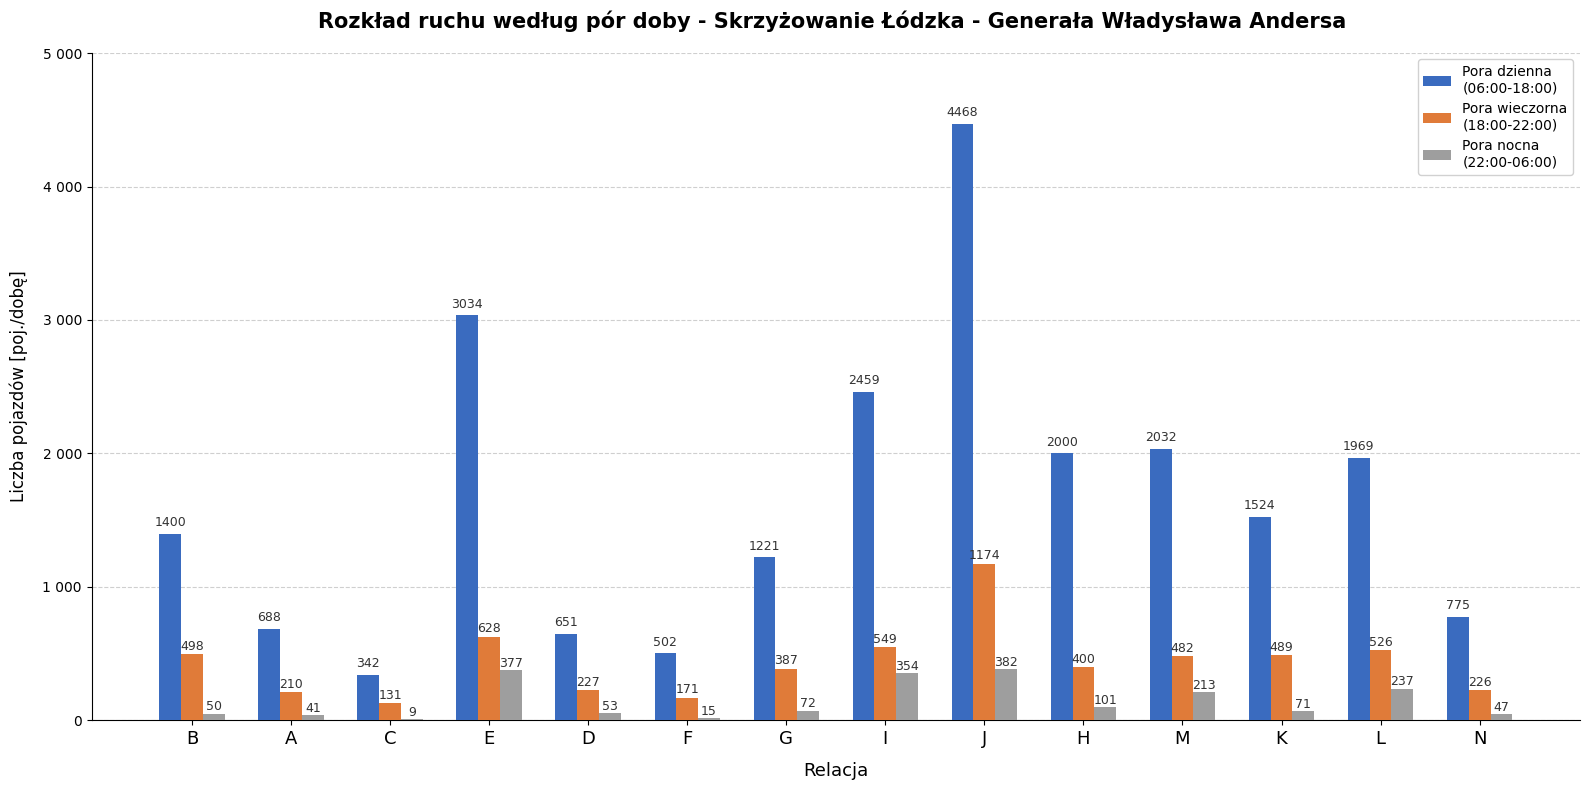

Wykres zapisany: wykres_pory_doby_Skrzyżowanie Łódzka - Generała Władysława Andersa .png


In [64]:
import matplotlib.ticker as mticker

# Funkcja do generowania nazwy pliku
def generuj_nazwe_pory(nr_tabeli, nazwa_punktu):
    return f'tab{nr_tabeli}_pory_{nazwa_punktu}.csv'

# Tworzymy nazwę pliku
plik_pory = generuj_nazwe_pory(NR_TAB_PORY, NAZWA_PUNKTU)

# Wczytujemy dane
tab_pory_plot = pd.read_csv(plik_pory, encoding='utf-8-sig')
df_plot = tab_pory_plot[tab_pory_plot['Pora'] != 'Suma'].copy()

pory_labels = [
    'Pora dzienna\n(06:00-18:00)',
    'Pora wieczorna\n(18:00-22:00)',
    'Pora nocna\n(22:00-06:00)'
]
kolory = PALETTE_PORY

x = np.arange(len(KOLEJNOSC_KIERUNKOW))
szerokosc = 0.22

fig, ax = plt.subplots(figsize=(16, 8))

for i, (_, wiersz) in enumerate(df_plot.iterrows()):
    kolor = kolory[i]
    label = pory_labels[i]
    wartosci = [wiersz[k] for k in KOLEJNOSC_KIERUNKOW]
    pozycje = x + (i - 1) * szerokosc

    bars = ax.bar(
        pozycje,
        wartosci,
        szerokosc,
        label=label,
        color=kolor,
        zorder=3
    )

    ymax_local = max(wartosci) if max(wartosci) > 0 else 1

    for bar, v in zip(bars, wartosci):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ymax_local * 0.008,
            f'{int(v)}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='normal',
            color=GREY_DARK
        )

ax.set_xticks(x)
ax.set_xticklabels(KOLEJNOSC_KIERUNKOW, fontsize=13)
ax.set_xlabel('Relacja', fontsize=13, labelpad=10)
ax.set_ylabel('Liczba pojazdów [poj./dobę]', fontsize=12, labelpad=10)
ax.set_title(
    f'Rozkład ruchu według pór doby - {NAZWA_PUNKTU}',
    fontsize=15,
    fontweight='bold',
    pad=18
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f'{int(val):,}'.replace(',', ' '))
)

ax.set_ylim(0, max(df_plot[KOLEJNOSC_KIERUNKOW].max()) * 1.12)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    fontsize=10,
    framealpha=0.9,
    loc='upper right',
    frameon=True,
    edgecolor=GREY_LIGHT
)

plt.tight_layout()

nazwa_pliku = f'wykres_pory_doby_{NAZWA_PUNKTU}.png'
plt.savefig(nazwa_pliku, dpi=180, bbox_inches='tight')
plt.show()

print(f"Wykres zapisany: {nazwa_pliku}")


In [ ]:
# ============================================================
# WYKRES: ROZKŁAD GODZINOWY RUCHU WEDŁUG RELACJI
# ============================================================
df['_suma_mech'] = df[KATEGORIE_MECHANICZNE].sum(axis=1)
df_pivot = (df.groupby(['Godzina', 'Kierunek'])['_suma_mech']
              .sum()
              .unstack(fill_value=0)
              .reindex(columns=KOLEJNOSC_KIERUNKOW, fill_value=0)
              .reindex(range(24), fill_value=0))

kolor_mapa = {k: PALETTE_QUALITATIVE[i % len(PALETTE_QUALITATIVE)] for i, k in enumerate(KOLEJNOSC_KIERUNKOW)}

fig, ax = plt.subplots(figsize=(16, 7))

for k in KOLEJNOSC_KIERUNKOW:
    wlot, manewr = KIERUNEK_MAPPING.get(k, (k, ''))
    etykieta = f'Wlot {wlot} {manewr}'.strip()

    ax.plot(range(24), df_pivot[k].values,
            label=etykieta,
            color=kolor_mapa[k],
            linewidth=2,
            marker='o', markersize=5)

ax.set_title(f'Rozkład godzinowy ruchu według relacji - {NAZWA_PUNKTU}', fontsize=14, pad=14)
ax.set_xlabel('Godzina', fontsize=12)
ax.set_ylabel('Natężenie ruchu [poj./h]', fontsize=12)
ax.set_xticks(range(24))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, df_pivot.values.max() * 1.15)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9, framealpha=0.9, loc='upper right', frameon=True, edgecolor=GREY_LIGHT, ncol=2)

plt.tight_layout()

nazwa_pliku = f'rozklad_godzinowy_relacje_{NAZWA_PUNKTU}.png'
plt.savefig(nazwa_pliku, dpi=180, bbox_inches='tight')
plt.show()

print(f"Wykres zapisany: {nazwa_pliku}")

In [66]:
import pandas as pd
import os

# Funkcja do generowania nazw plików
def generuj_nazwe_pliku(numer_tabeli, typ):
    return f'tab{numer_tabeli}_{typ}_{NAZWA_PUNKTU}.csv'

# Lista plików do zapisania w Excelu
plik_typy = ['parametry', 'kierunki', 'pory', 'struktura', 'godzinowa']
csv_files = [generuj_nazwe_pliku(NR_TABELI_START + i, typ) for i, typ in enumerate(plik_typy)]

# Folder, w którym zapisujesz pliki (w tym samym folderze co skrypt)
folder_path = os.getcwd()

# Funkcja do tworzenia pliku Excel z plików CSV
def create_excel_from_csvs(folder, files, nazwa_punktu, output_filename='wynik_tabele_{NAZWA_PUNKTU}.xlsx'):
    filename = output_filename.replace('{NAZWA_PUNKTU}', nazwa_punktu)
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for file in files:
            file_path = os.path.join(folder, file)
            df = pd.read_csv(file_path, encoding='utf-8-sig')
            sheet_name = os.path.splitext(file)[0]
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    print(f"Plik {filename} został utworzony.")

# Wywołanie funkcji
create_excel_from_csvs(folder_path, csv_files, NAZWA_PUNKTU)



Plik wynik_tabele_Skrzyżowanie Łódzka - Generała Władysława Andersa .xlsx został utworzony.


C:\Users\chmieja5\Downloads\Drogi\.venv\Lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


In [67]:
import pandas as pd
import os

def generuj_prompt_analizy(nazwa_punktu, nr_punktu, miasto, folder_path=None):
    """
    Generuje prompt do analizy ruchu drogowego na podstawie plików CSV
    i zapisuje go do pliku.
    
    Args:
        nazwa_punktu (str): Nazwa punktu pomiarowego (np. 'Most im. Józefa Piłsudskiego')
        nr_punktu (str): Numer punktu (np. '1')
        miasto (str): Nazwa miasta (np. 'Toruń')
        folder_path (str): Ścieżka do folderu z plikami (domyślnie bieżący folder)
    
    Returns:
        str: Wygenerowany prompt
    """
    
    if folder_path is None:
        folder_path = os.getcwd()
    
    # Funkcja do generowania nazw plików
    def generuj_nazwe_pliku(numer_tabeli, typ):
        return f'tab{numer_tabeli}_{typ}_{nazwa_punktu}.csv'
    
    # Lista typów plików
    plik_typy = ['parametry', 'kierunki', 'pory', 'struktura', 'godzinowa']
    
    # Generowanie listy plików (analogicznie do create_excel_from_csvs)
    NR_TABELI_START = nr_punktu + '1'  # np. '1' + '1' = '11'
    csv_files = [generuj_nazwe_pliku(NR_TABELI_START[0] + str(int(NR_TABELI_START[1]) + i), typ) 
                 for i, typ in enumerate(plik_typy)]
    
    # Wczytanie danych z plików CSV
    dataframes = {}
    
    for i, typ in enumerate(plik_typy):
        numer_tabeli = nr_punktu + str(i + 1)  # np. '1' + '1' = '11', '1' + '2' = '12'
        plik = generuj_nazwe_pliku(numer_tabeli, typ)
        file_path = os.path.join(folder_path, plik)
        
        try:
            df = pd.read_csv(file_path, encoding='utf-8-sig')
            dataframes[typ] = df
            print(f"Wczytano: {plik}")
        except FileNotFoundError:
            if typ == 'godzinowa':
                # Plik godzinowa jest opcjonalny
                dataframes[typ] = None
                print(f"Plik opcjonalny nie znaleziony: {plik}")
            else:
                error_msg = f"Błąd: Nie znaleziono pliku {plik}"
                print(error_msg)
                return error_msg
    
    # Budowanie promptu
    prompt = f"""
    
    Wygeneruj plik docx na bazie tego polecenie. marginesy ustaw jako normalne.
Dołączam też do tego diagramy, tabele i wykresy. Dołącz je w odpowiednich miejscach tak żeby pasowały do kontekstu. Dodaj im podpisy, numeruj zdjęcia i tabele. Jeżeli nie moższe dodać zdjęcia to zrób przynajmniej placeholder.

Musimy mieć następujące podpunkty dla punktu pomiarowego (trzymaj się tego ściśle):
1.1. Lokalizacja i parametry pomiaru
	rysunek obraz z kamery + Opis + Tabela Parametry pomiaru.
1.2. Organizacja ruchu i geometria skrzyżowania
	opis + Diagram relacji ruchu + 3 diagramy natężeń ruchu pierwszy to szczyt dobowy, drugi szczyt popołudniowy i 3 szczyt wieczorny.
1.3. Ruch według kierunków i relacji
	opis + Tabela Zestawienie relacji ruchu (SDR) i szczytów godzinowych.
1.4. Rozkład dobowy i pory ruchu
	opis + Tabela Ruch według pór doby + rysunek - wykre sudziałów pór doby
1.5. Struktura rodzajowa ruchu
	Tabela Struktura rodzajowa ruchu +  opis + tabela Struktura rodzajowa pojazdów w dobie (5. Struktura godzinowa wg relacji), jest długa ale musi być cała. Tak na pewno. Nie pytaj ponownie.

Wszystkie tabele i grafiki muszą mieć oznaczenia. Bedzie tutaj 6 punktów pomiarowych. To jest punkt pierwszy więc oznaczenia tabel i grafik muszą być np. 1.1, 1.2.
    Przebuduj teksty ze wzorów bazując na danych z CSV. 
Miasto pomiarów to {miasto}. 
Punkt pomiarowy: {nazwa_punktu}

Mapowanie kierunków:

{KIERUNEK_MAPPING}


jeżeli w mapowaniu kierunków mamy wartość np. 'A-B': ('WSCH', 'Prawo') to oznacza że A-B to Wlot Wschodni i kierunek w prawo, chce żebyś tak opisywał kierunki i relacje i nie pisał tych oznaczeń A-E w ogóle. Jeżeli w jakieś tabeli się to pojawia np. Relacja i lista takich A-e, C-f... usuń tę kolumnę.

Mam takie teksty do przebudowania:

1. OPIS OGÓLNY
wzór: Punkt pomiarowy SK1_B_Sępoleńska zlokalizowany jest na skrzyżowaniu w rejonie ulicy Sępoleńska w Bydgoszczy. Skrzyżowanie charakteryzuje się wyjątkowo nietypowym rozkładem ruchu, w którym relacje skrętne odgrywają kluczową rolę, obsługując prawie połowę całkowitego ruchu drogowego

2. ANALIZA KIERUNKOWA RUCHU
wzór: Punkt pomiarowy Most im. Józefa Piłsudskiego wyróżnia się wyjątkowo nietypowym rozkładem ruchu:
Relacje osiowe (L+P): 4 054 poj./dobę (49,5% SDR)
•	Relacja P: 2 106 poj./dobę (25,7%) – główna relacja osiowa
•	Relacja L: 1 948 poj./dobę (23,8%)
Przewaga P nad L wynosi zaledwie 8,1%, co wskazuje na zbilansowany ruch wahadłowy
Relacje skrętne główne (L1+Z1): 3 622 poj./dobę (44,2% SDR)
•	Relacja L1: 1 818 poj./dobę (22,2%) – druga co do wielkości relacja w punkcie
•	Relacja Z1: 1 804 poj./dobę (22,0%) – trzecia co do wielkości relacja w punkcie
Te dwie relacje skrętne obsługują prawie połowę całkowitego ruchu, co jest unikalną cechą tego skrzyżowania
•	Relacje pomocnicze (P1+Z): 520 poj./dobę (6,3% SDR)
Obsługują ruch lokalny o mniejszym znaczeniu.
Tak wysoki udział relacji skrętnych L1 i Z1 wskazuje na szczególne znaczenie tego skrzyżowania jako węzła dystrybucyjnego, który kieruje ruch z osi północ-połudód (L-P) do obszarów PDodnich miasta. Relacje L1 i Z1 pełnią funkcję głównych tras połączeniowych między różnymi rejonami miejskimi, a nie jedynie lokalnych dróg dojazdowych.
Rozkład szczytów godzinowych:
•	Relacja P – szczyt popołudniowy o 15:00 (173 poj./h) – powroty z pracy
•	Relacja L – szczyt popołudniowy o 15:00 (154 poj./h) – powroty z pracy
•	Relacja L1 – szczyt popołudniowy o 16:00 (154 poj./h) – ruch lokalny związany z powrotami
•	Relacja Z1 – szczyt popołudniowy o 14:00 (151 poj./h) – początek ruchu powrotnego przez relację skrętną

3. CHARAKTERYSTYKA ROZKŁADU DOBOWEGO
wzór: Charakterystyka rozkładu dobowego
Zdecydowana większość ruchu (79,7%) koncentruje się w porze dziennej (06:00–18:00), co jest typowe dla dróg obsługujących ruch wahadłowy praca–dom. Pora nocna stanowi 8,3% SDR (680 poj.), przy czym:
•	Relacje L i P w porze nocnej (łącznie 386 poj.) wskazują na obecność ruchu tranzytowego
•	Relacja Z1 w porze nocnej (162 poj.) sugeruje istotne znaczenie połączenia PDodniego również poza godzinami szczytu
Niski udział relacji Z i P1 w porze nocnej (łącznie 14 poj.) potwierdza ich lokalno-dojazdowy charakter.


4. INTERPRETACJA STRUKTURY RODZAJOWEJ
wzór: Struktura ruchu na skrzyżowaniu SK1_B_Sepolenska charakteryzuje się:
•	Samochody osobowe: 69,8% SDR – nieco niższy udział niż w innych punktach, co wskazuje na większe znaczenie ruchu towarowego
•	Pojazdy dostawcze: 10,9% – umiarkowany udział świadczący o aktywności gospodarczej
•	Pojazdy ciężkie łącznie: 16,3% (ciężarowe z naczepami + ciężarowe) – bardzo wysoki udział, wskazujący na znaczenie drogi dla ruchu towarowego międzyregionalnego
•	Transport publiczny: 1,3% (autobusy + mikrobusy) – niewielki, co potwierdza dominację transportu indywidualnego
Ruch niezmotoryzowany stanowi 1,1% (93 użytkowników/dobę), w tym:
•	Rowerzyści: 24 osoby – skoncentrowani głównie na relacji P1 (10 osób)
•	Piesi: 69 osób – największa obecność na relacji Z1 (28 osób)


---

DANE Z PLIKÓW CSV:

1. PARAMETRY:
{dataframes['parametry'].to_string(index=False)}

2. KIERUNKI:
{dataframes['kierunki'].to_string(index=False)}

3. PORY DOBY:
{dataframes['pory'].to_string(index=False)}

4. STRUKTURA RODZAJOWA:
{dataframes['struktura'].to_string(index=False)}
"""
    
    if dataframes['godzinowa'] is not None:
        prompt += f"""
5. DANE GODZINOWE (To jest bardzo ważne - Wstaw to na samym końcu):
{dataframes['godzinowa'].to_string(index=False)}
"""
    
    prompt += """
---

Proszę o wygenerowanie pełnych tekstów analitycznych dla wszystkich 5 sekcji, bazując na rzeczywistych danych z CSV.
"""
    
    # Zapisanie promptu do pliku
    nazwa_pliku_prompt = f'ai_prompt_{nazwa_punktu}.txt'
    with open(nazwa_pliku_prompt, 'w', encoding='utf-8') as f:
        f.write(prompt)
    
    print(f"Plik {nazwa_pliku_prompt} został utworzony.")
    
    return prompt


prompt = generuj_prompt_analizy(NAZWA_PUNKTU, NR_PUNKTU, MIASTO)


Wczytano: tab21_parametry_Skrzyżowanie Łódzka - Generała Władysława Andersa .csv
Wczytano: tab22_kierunki_Skrzyżowanie Łódzka - Generała Władysława Andersa .csv
Wczytano: tab23_pory_Skrzyżowanie Łódzka - Generała Władysława Andersa .csv
Wczytano: tab24_struktura_Skrzyżowanie Łódzka - Generała Władysława Andersa .csv
Wczytano: tab25_godzinowa_Skrzyżowanie Łódzka - Generała Władysława Andersa .csv
Plik ai_prompt_Skrzyżowanie Łódzka - Generała Władysława Andersa .txt został utworzony.



Tabela 26. Dane do wykresu rozkładu według pór doby – Punkt Skrzyżowanie Łódzka - Generała Władysława Andersa 

                        Pora Etykieta wykresu  Liczba pojazdów [poj./dobę] Udział [%]
  Pora dzienna (06:00-18:00)   Dzienna\n06-18                        23065      74.0%
Pora wieczorna (18:00-22:00) Wieczorna\n18-22                         6098      19.6%
    Pora nocna (22:00-06:00)     Nocna\n22-06                         2022       6.5%


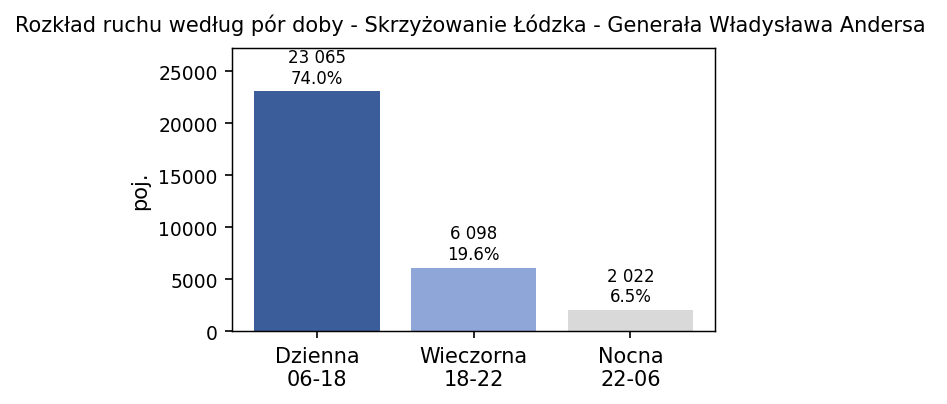

Wykres zapisany: wykres_slupkowy_pory_doby_Skrzyżowanie Łódzka - Generała Władysława Andersa .png


In [68]:
# ============================================================
# MODUŁ 8: DYNAMICZNY WYKRES PÓR DOBY + TABELA
# ============================================================
NR_TAB_PORY_WYKRES = NR_TABELI_START + 5

# Upewniamy się, że pracujemy na tabeli bez wiersza "Suma"
df_pory_wykres = tab_pory[tab_pory['Pora'] != 'Suma'].copy()

# Mapowanie nazw por na krótsze etykiety do wykresu
mapa_etykiet = {
    'Pora dzienna (06:00-18:00)': 'Dzienna\n06-18',
    'Pora wieczorna (18:00-22:00)': 'Wieczorna\n18-22',
    'Pora nocna (22:00-06:00)': 'Nocna\n22-06'
}

# Zachowanie właściwej kolejności
kolejnosc_por = [
    'Pora dzienna (06:00-18:00)',
    'Pora wieczorna (18:00-22:00)',
    'Pora nocna (22:00-06:00)'
]

df_pory_wykres['kolejnosc'] = df_pory_wykres['Pora'].map({v: i for i, v in enumerate(kolejnosc_por)})
df_pory_wykres = df_pory_wykres.sort_values('kolejnosc')

# Dane do wykresu
labels = [mapa_etykiet[p] for p in df_pory_wykres['Pora']]
values = df_pory_wykres['Sum'].astype(int).tolist()
shares = [round(v / sdr_total * 100, 1) for v in values]
colors = PALETTE_PORY

# Tabela pomocnicza
tab_pory_wykres = pd.DataFrame({
    'Pora': df_pory_wykres['Pora'].tolist(),
    'Etykieta wykresu': labels,
    'Liczba pojazdów [poj./dobę]': values,
    'Udział [%]': [f'{x:.1f}%' for x in shares]
})

print(f"\nTabela {NR_TAB_PORY_WYKRES}. Dane do wykresu rozkładu według pór doby – Punkt {NAZWA_PUNKTU}\n")
print(tab_pory_wykres.to_string(index=False))

tab_pory_wykres.to_csv(
    f'tab{NR_TAB_PORY_WYKRES}_wykres_pory_doby_{NAZWA_PUNKTU}.csv',
    index=False,
    encoding='utf-8-sig'
)

# --- Wykres ---
fig, ax = plt.subplots(figsize=(4.2, 2.8), dpi=150)

bars = ax.bar(labels, values, color=colors, width=0.8)

ax.set_ylabel('poj.', fontsize=10)
ax.set_ylim(0, max(values) * 1.18)

offset = max(values) * 0.02

for bar, val, share in zip(bars, values, shares):
    label = f'{val:,}\n{share:.1f}%'.replace(',', ' ')
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + offset,
        label,
        ha='center',
        va='bottom',
        fontsize=8
    )

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(0.7)

ax.set_title(f'Rozkład ruchu według pór doby - {NAZWA_PUNKTU}', fontsize=10, pad=8)

plt.tight_layout()

nazwa_pliku = f'wykres_slupkowy_pory_doby_{NAZWA_PUNKTU}.png'
plt.savefig(nazwa_pliku, dpi=180, bbox_inches='tight')
plt.show()

print(f"Wykres zapisany: {nazwa_pliku}")
